In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/raw/raw-dataset.csv')

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CUST_ID                 8950 non-null   str    
 1   BALANCE                 8950 non-null   float64
 2   PURCHASES               8950 non-null   float64
 3   ONEOFF_PURCHASES        8950 non-null   float64
 4   INSTALLMENTS_PURCHASES  8950 non-null   float64
 5   CASH_ADVANCE            8950 non-null   float64
 6   CREDIT_LIMIT            8949 non-null   float64
 7   PAYMENTS                8950 non-null   float64
dtypes: float64(7), str(1)
memory usage: 559.5 KB


In [43]:
# def skewness(array: np.array):
#     mean = array.mean()
#     distance_to_mean = np.subtract(array, mean)
#     std = np.sqrt(np.divide(np.pow(distance_to_mean, 2).sum(), len(array)))
#     return np.divide(np.pow(np.divide(distance_to_mean, std), 3).sum(), len(array)), mean,

/tmp/ipykernel_30931/3674897805.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_30931/3674897805.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_30931/3674897805.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_30931/3674897805.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_30931/3674897805.py:16: UserWarning: No artists with labels found to put in legend.  Note

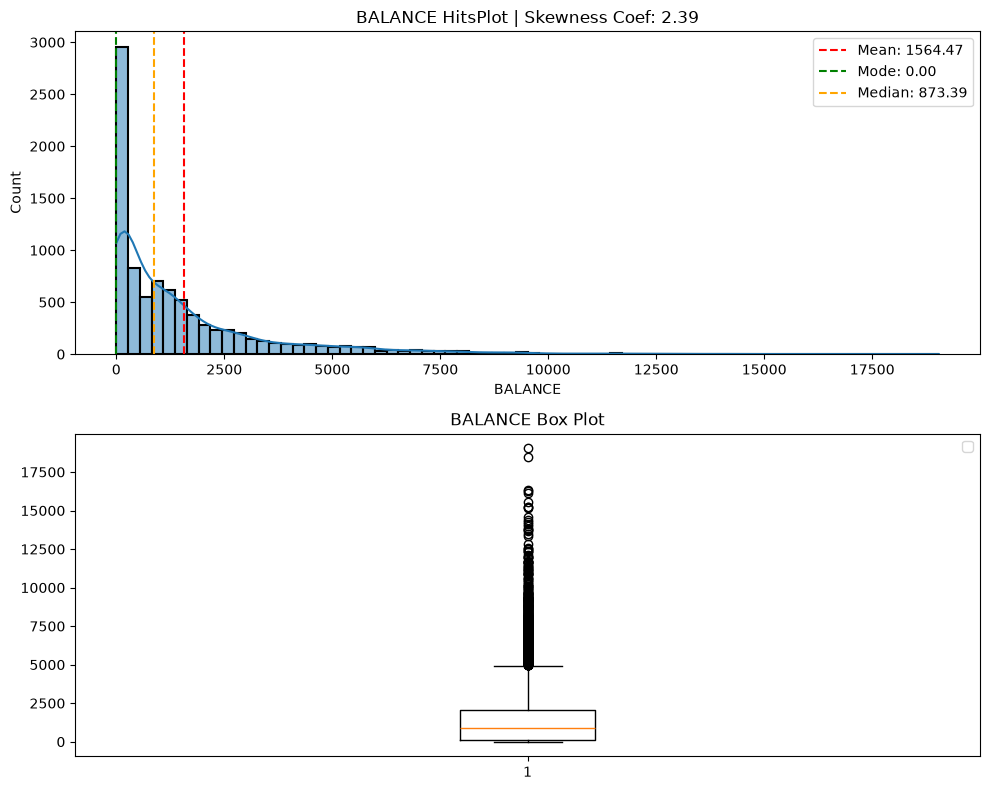

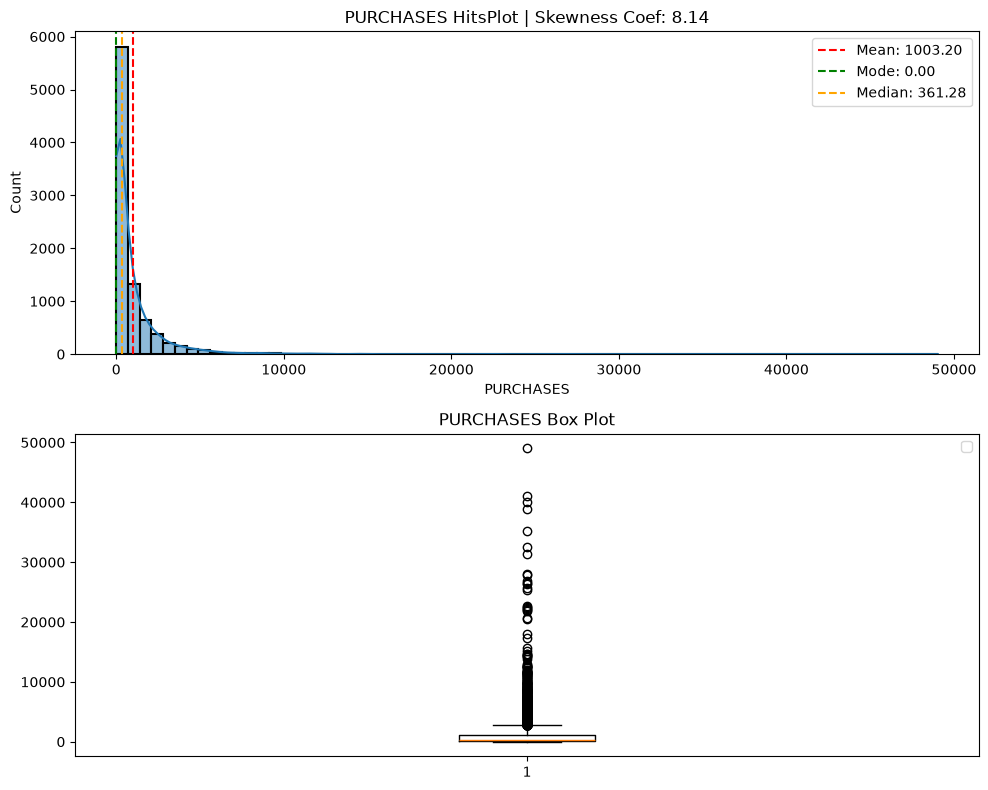

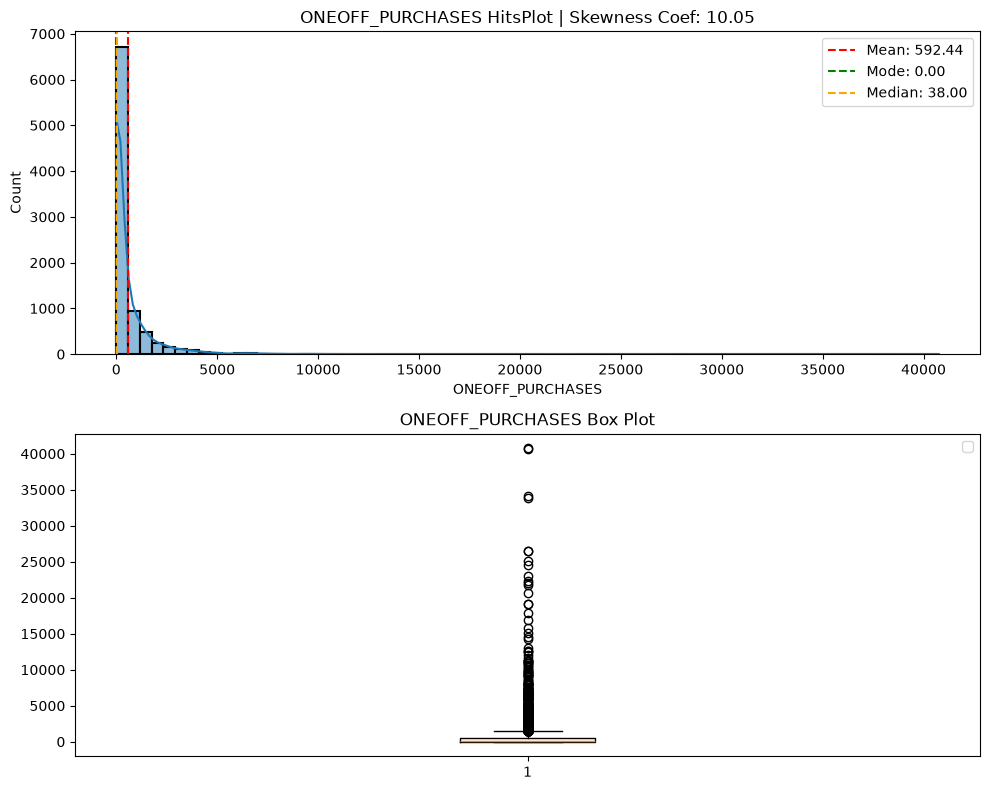

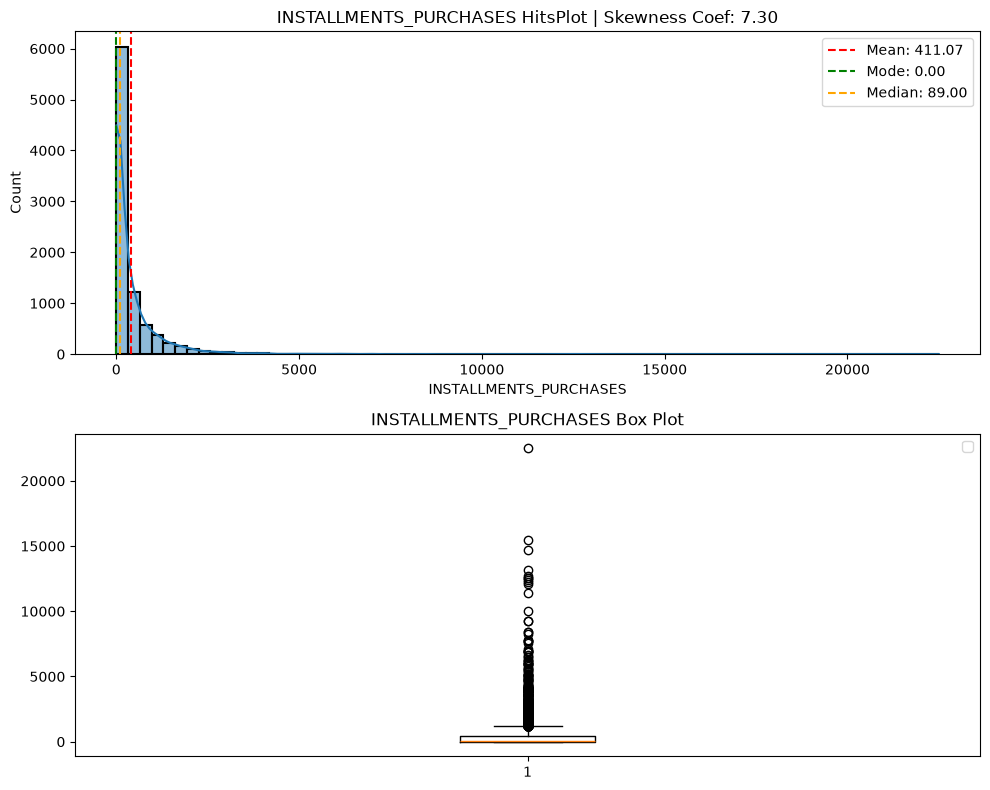

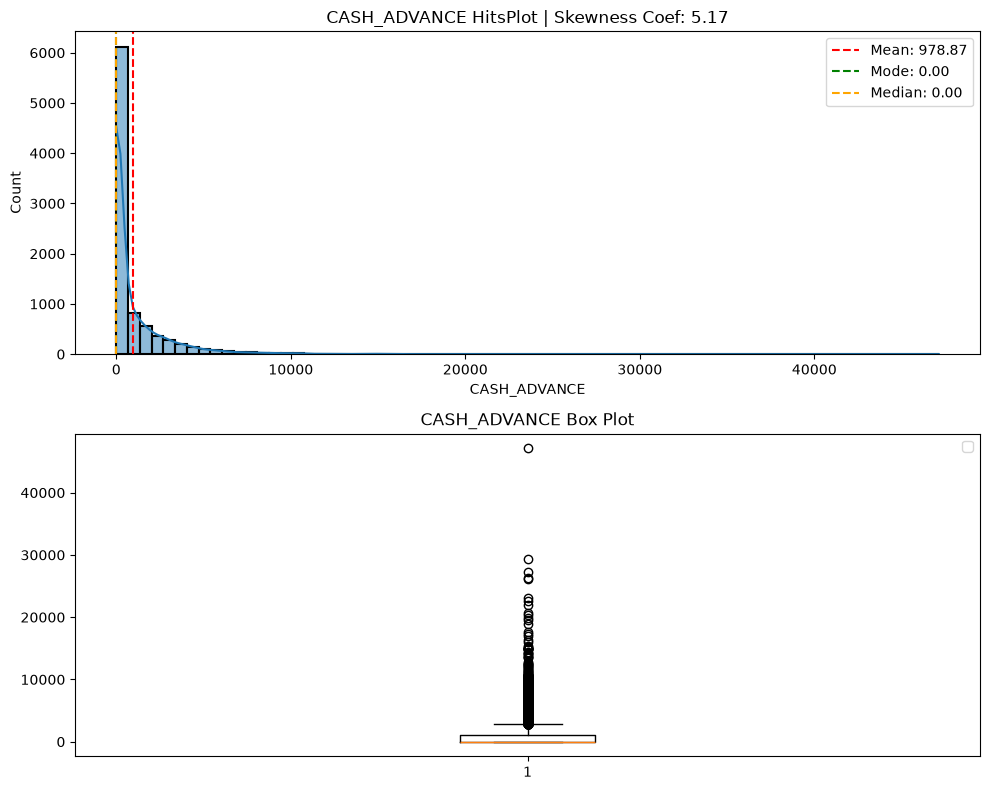

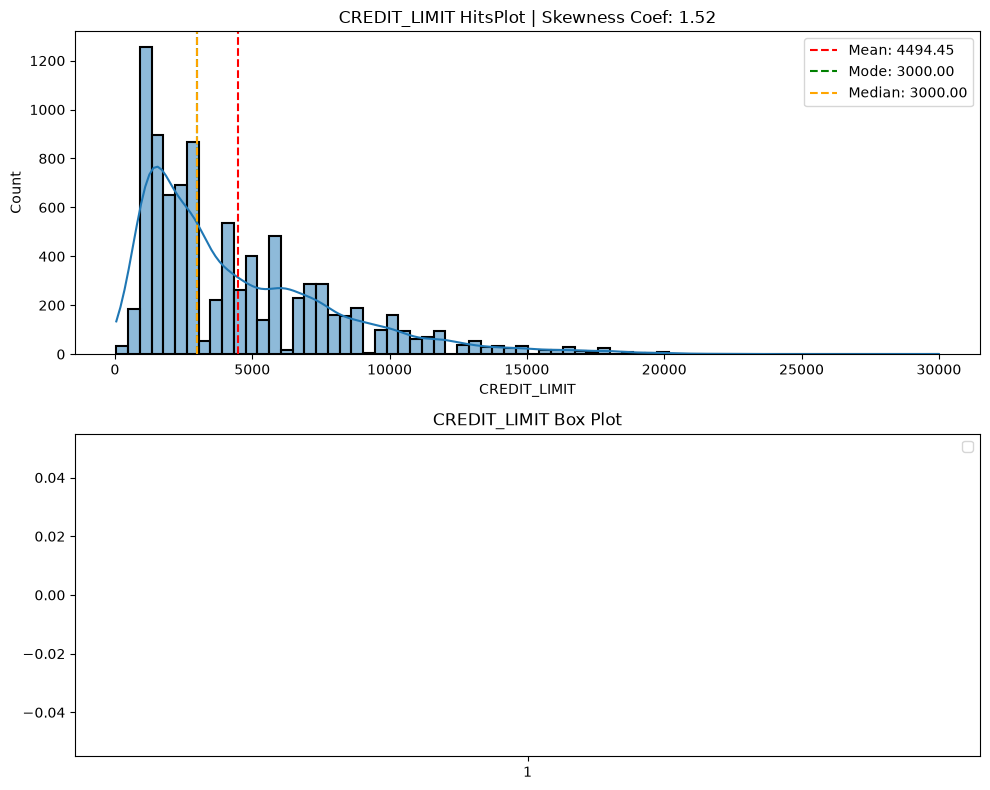

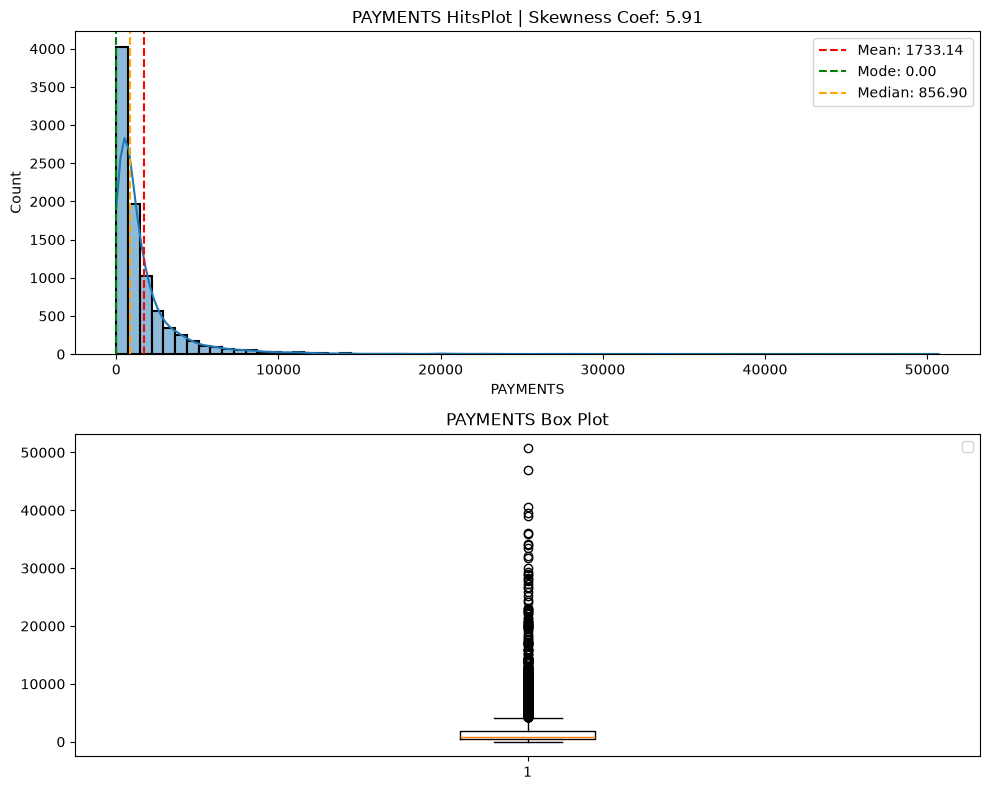

In [44]:
for column in df.select_dtypes(include='number').columns:
    mean = df[column].mean()
    mode = df[column].mode()[0]
    median = df[column].median()
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))
    sns.histplot(df[column], edgecolor='black', linewidth=1.5, ax=ax1, kde=True, bins=70)
    ax1.axvline(mean, label=f'Mean: {mean:.2f}', linestyle='--', linewidth=1.5, color='red')
    ax1.axvline(mode, label=f'Mode: {mode:.2f}',linestyle='--', linewidth=1.5, color='green')
    ax1.axvline(median, label=f'Median: {median:.2f}',linestyle='--', linewidth=1.5, color='orange')
    # ax.axvline(skewness_cof, label=f'Skewness: {skewness_cof:.2f}',linestyle='--', linewidth=1.5, color='red')
    ax1.legend()
    skew = df[column].skew()
    ax1.set_title(f'{column} HitsPlot | Skewness Coef: {skew:.2f}')

    ax2.boxplot(df[column])
    ax2.legend()
    ax2.set_title(f'{column} Box Plot')
    plt.tight_layout()

<Axes: >

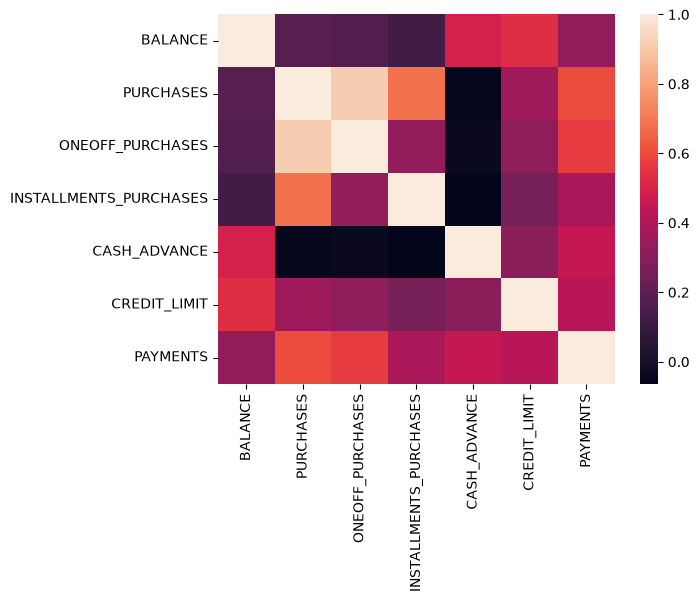

In [45]:
sns.heatmap(df.select_dtypes(include='number').corr())

In [46]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].mean())

In [49]:
df.to_csv('../data/processed/clean_df.csv')